In [1]:
# Import libraries
import numpy as np
import pandas as pd
import sklearn
from joblib import dump, load

import shap

IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


# Without-sampling

In [2]:
# Import mlp model
model_mlp = load("models/without-sampling/netflow/MLP_Regressor_Classifier.joblib")

Trying to unpickle estimator LabelBinarizer from version 0.24.2 when using version 1.0.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/modules/model_persistence.html#security-maintainability-limitations
Trying to unpickle estimator MLPClassifier from version 0.24.2 when using version 1.0.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/modules/model_persistence.html#security-maintainability-limitations


In [3]:
dataset = pd.read_csv("datasets/normalized/D2testSqlNormalized.csv")

X = dataset.drop(columns=["Label"])
y = dataset["Label"]

In [4]:
explainer = shap.Explainer(model_mlp.predict, X.values)
shap_values = explainer(X.values)


shap_values.feature_names = X.columns.tolist()

PermutationExplainer explainer: 57230it [14:15, 66.37it/s]                           


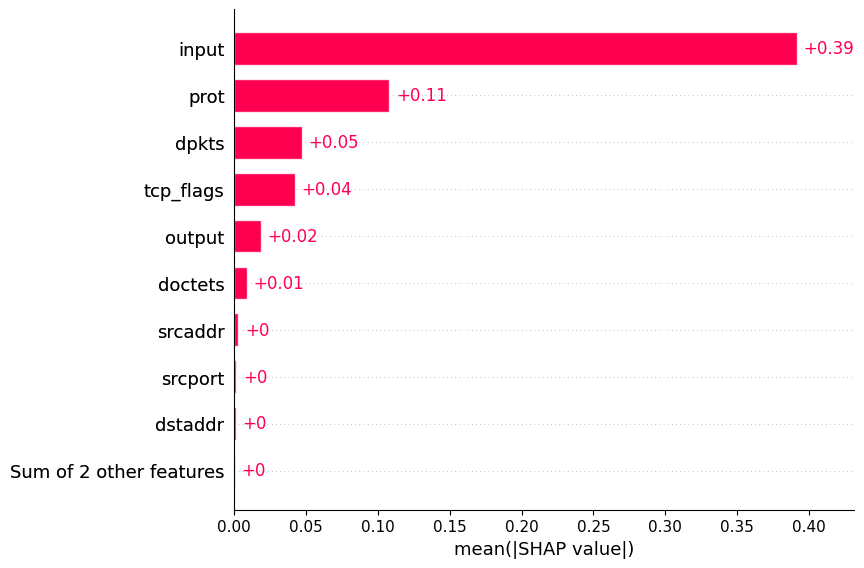

In [5]:
# Stacked force plot
shap.initjs()
# Absolute mean SHAP
shap.plots.bar(shap_values)

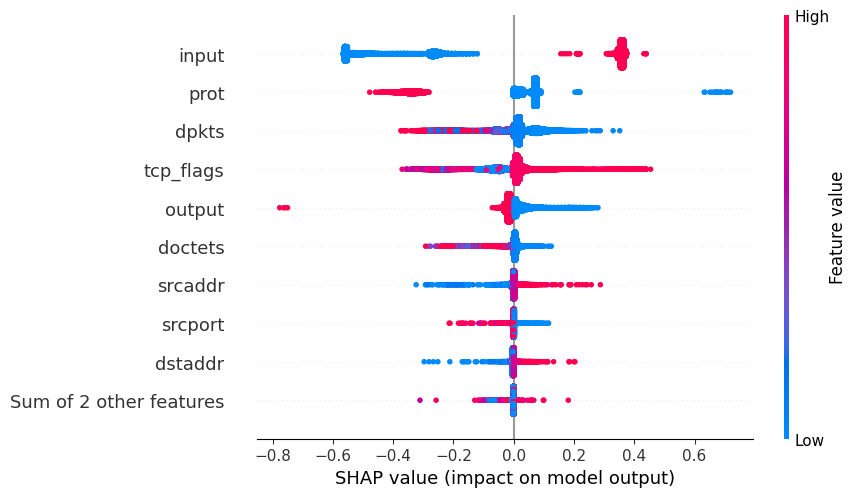

In [6]:
# Beeswarm plot
shap.plots.beeswarm(shap_values)

# Sampling

In [7]:
# Import mlp model
model_mlp = load("models/sampling/netflow/MLP_Regressor_Classifier.joblib")

Trying to unpickle estimator LabelBinarizer from version 0.24.2 when using version 1.0.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/modules/model_persistence.html#security-maintainability-limitations
Trying to unpickle estimator MLPClassifier from version 0.24.2 when using version 1.0.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/modules/model_persistence.html#security-maintainability-limitations


In [8]:
dataset = pd.read_csv("datasets/normalized/D5testSqlNormalized.csv")

X = dataset.drop(columns=["Label"])
y = dataset["Label"]

In [9]:
explainer = shap.Explainer(model_mlp.predict, X.values)
shap_values = explainer(X.values)


shap_values.feature_names = X.columns.tolist()

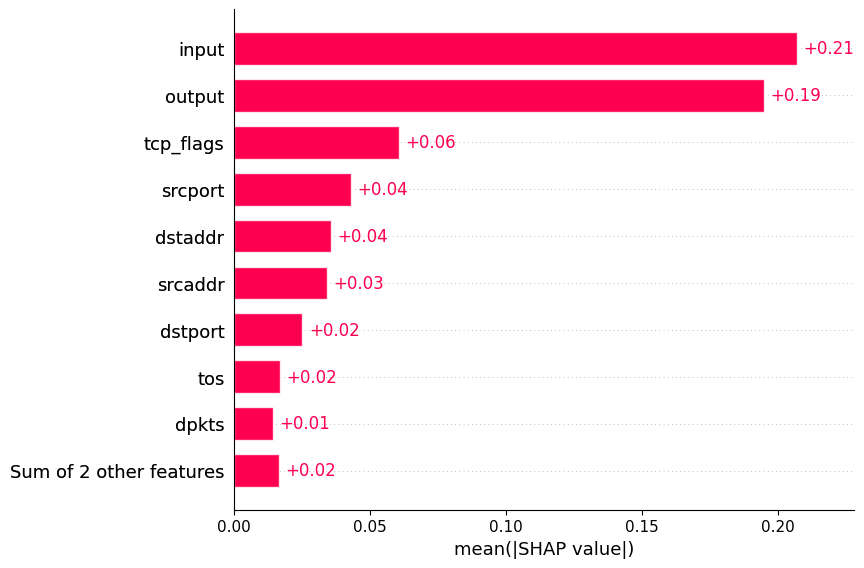

In [10]:
# Absolute mean SHAP
shap.plots.bar(shap_values)

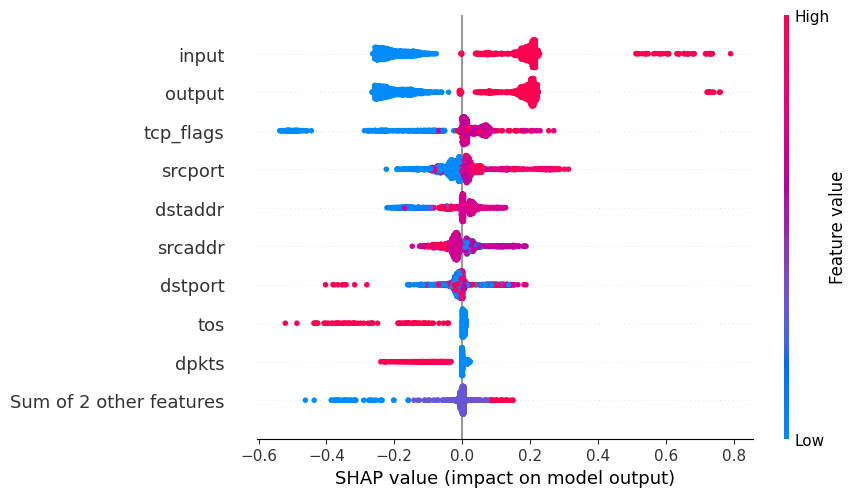

In [11]:
# Beeswarm plot
shap.plots.beeswarm(shap_values)